# Evaluación 2 - Solar Scope

---

**Autores:**

1. Bastian Ñiripil : ba.niripil@duocuc.cl
2. Luis Perez : lua.perezb@duocuc.cl

**Fecha de Creación:** Marzo 2026

**Versión:** 1.0  

---

## Descripción

Este notebook corresponde al desarrollo de la entrega 2 de la asignatura Minería de Datos de DuocUC - Sede Concepción.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.9. A continuación se listan las bibliotecas necesarias:

- pandas
- numpy
- matplotlib
- seaborn

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```bash
import pandas as pd
print(pd.__version__)
```

In [1]:
# Descarga del dataset de clima
# Este comando descargará los datos de radiación solar y nubosidad para las localidades de operación
!wget https://raw.githubusercontent.com/T013D0/BIY7121_Mineria_De_Datos/refs/heads/main/data_clima_2025_final.csv

--2026-05-14 18:45:07--  https://raw.githubusercontent.com/T013D0/BIY7121_Mineria_De_Datos/refs/heads/main/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv’

data_clima_2025_fin 100%[===================>]   4.32M  --.-KB/s    in 0.07s   

2026-05-14 18:45:08 (59.9 MB/s) - ‘data_clima_2025_final.csv’ saved [4527300/4527300]



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cargar los datos
data = pd.read_csv('data_clima_2025_final.csv')
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


# 0. Contexto de Negocio y Definición de Fases Metodología CRISP-DM

## Contexto del DataFrame

**Solar Scope** es una empresa chilena dedicada a la generación de energías renovables que busca expandir sus operaciones instalando nuevas plantas de paneles solares fotovoltaicos en Chile. Debido a la extensa y singular geografía del país, la eficiencia y rentabilidad de los paneles solares varían drásticamente dependiendo de la zona y la época del año.

La empresa opera actualmente en cuatro localidades estratégicas:
- Concepción
- Temuco
- Valdivia
- Punta Arenas

### Problemática

La instalación de una planta solar representa una inversión de alto costo. Seleccionar una localidad con una alta tasa de nubosidad o baja radiación solar impactará negativamente en la generación de energía, afectando la rentabilidad del proyecto y el suministro a la red.

Por lo tanto, Solar Scope necesita analizar datos climáticos históricos para:
- Identificar las ubicaciones y temporalidades óptimas que maximicen la captura de energía solar
- Minimizar los riesgos por nubosidad
- Evaluar patrones estacionales de radiación solar

---

## ¿De dónde provienen los datos?

Los datos utilizados en este estudio provienen de la plataforma **open-meteo.com**, una fuente abierta y confiable de información meteorológica. El conjunto de datos incluye registros horarios recopilados durante el año 2025 para las distintas localidades de operación de la empresa.

El dataset incluye variables climáticas clave como:
- Temperatura a 2 metros
- Humedad relativa
- Precipitación
- **Cobertura nubosa** ✓
- **Duración de la radiación solar** ✓
- Variables de identificación geográfica (localidad, latitud, longitud)
- Indicadores temporales (hora, día, mes)

---

## Definición de Objetivos

### Objetivo Fase 1 (Business Understanding)

Este DataFrame concentra información meteorológica clave para las operaciones de Solar Scope en Concepción, Temuco, Valdivia y Punta Arenas, permitiendo analizar el comportamiento de la radiación solar y su relación con la nubosidad.

A partir de estos datos, la empresa busca definir KPI orientados a rentabilidad y sostenibilidad, evaluando la disponibilidad de radiación solar en diferentes periodos y localidades.

El objetivo es apoyar la toma de decisiones operativas e inversoras mediante indicadores claros alineados con las necesidades del negocio.

### Objetivo Fase 2 (Data Understanding)

En la fase de Data Understanding, el objetivo es explorar y comprender en profundidad el DataFrame disponible, evaluando la calidad, consistencia y relevancia de las variables meteorológicas para el negocio de Solar Scope.

Esto incluye:
- Identificar patrones iniciales de radiación solar
- Detectar relaciones entre nubosidad y duración solar
- Evaluar posibles comportamientos diferenciados por localidad
- Detectar valores atípicos o inconsistencias en los datos

Este entendimiento permitirá validar que los datos de open-meteo.com son adecuados para el análisis posterior y la construcción de KPI y modelos predictivos confiables.

En esta sección se llevará a cabo un análisis preliminar para ver el contexto del dataframe y del negocio en sí. Se verificarán los tipos de datos y se definirá en un diccionario cuál es su significado.

In [ ]:
data.info(verbose=True, show_counts=True, memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

A primera vista se ve que todas las filas tienen datos completos con respecto a ciertas variables. El tipo de datos que contiene el dataframe incluye object, float e int. Hay 33,024 registros repartidos en 15 columnas a través del dataframe.

Esto garantiza una buena cobertura de datos para el análisis de radiación solar durante todo el año 2025.

## Diccionario de Datos

Este diccionario de datos fue elaborado con el objetivo de facilitar la comprensión del negocio y de las variables meteorológicas utilizadas, permitiendo interpretar correctamente el significado, la unidad y el contexto de cada dato.

Su uso contribuye a mejorar el análisis y la toma de decisiones basadas en información clara y estructurada.

| Variable                | Tipo de dato | Unidad              | Descripción |
|-------------------------|-------------|---------------------|-------------|
| date                    | object      | —                   | Fecha y hora del registro meteorológico correspondiente a la observación. |
| temperature_2m          | float64     | °C                  | Temperatura del aire medida instantáneamente a 2 metros sobre el nivel del suelo. |
| relative_humidity_2m    | float64     | %                   | Humedad relativa del aire medida instantáneamente a 2 metros sobre el nivel del suelo. |
| apparent_temperature    | float64     | °C                  | Temperatura aparente o sensación térmica, calculada considerando viento, humedad relativa y radiación solar. |
| precipitation           | float64     | mm                  | Precipitación total acumulada durante la hora anterior, incluyendo lluvia, chubascos y nieve. |
| cloud_cover             | float64     | %                   | **Porcentaje de cobertura nubosa total del cielo en el instante de medición.** |
| wind_speed_10m          | float64     | km/h                | Velocidad del viento medida a 10 metros sobre el nivel del suelo. |
| wind_direction_10m      | float64     | grados (°)          | Dirección desde donde proviene el viento, medida a 10 metros sobre el nivel del suelo. |
| rain                    | float64     | mm                  | Cantidad de lluvia acumulada durante la hora anterior proveniente de sistemas meteorológicos de gran escala. |
| is_day                  | float64     | —                   | Indicador binario: 1 si el registro corresponde a horario diurno, 0 si es nocturno. |
| **sunshine_duration**   | float64     | segundos            | **Duración de la radiación solar directa acumulada durante los 15 minutos previos a la observación.** |
| Localidad               | object      | —                   | Localidad geográfica donde se realizó la medición. |
| latitud                 | float64     | grados decimales    | Coordenada geográfica de latitud del punto de muestreo. |
| longitud                | float64     | grados decimales    | Coordenada geográfica de longitud del punto de muestreo. |
| is_rainy_hour           | int64       | —                   | Variable booleana que indica si durante la hora se registró lluvia (1) o no (0). |

# Fase 1

---

## 1. Identifica Correctamente dos KPI

## KPI 1: Porcentaje de Utilización de Capacidad

**Nombre del KPI:** "Porcentaje de Utilización de Capacidad Instalada"

**Propósito de Negocio:** Rentabilidad y Eficiencia Operativa. Medir la viabilidad económica de una localidad midiendo el porcentaje de horas al año con condiciones óptimas de radiación solar (baja nubosidad).

**Definición:** Es el porcentaje de horas al año en las que la cobertura nubosa se mantiene por debajo de un umbral crítico (ej. <40%), permitiendo una generación de energía eficiente.

**Variables:** `cloud_cover`, `is_day`, `date`, `Localidad`

**Interpretación:**
- Si es **alto (>75%)**: La localidad tiene condiciones climáticas favorables para la generación solar. Buena inversión.
- Si es **bajo (<50%)**: La localidad tiene alta nubosidad persistente. Riesgo de baja rentabilidad.

---

## KPI 2: Porcentaje de Proyectos Instalados en Zonas Óptimas

**Nombre del KPI:** "Tasa de Zonificación Óptima para Instalación"

**Propósito de Negocio:** Decisión Estratégica de Expansión. Identificar qué localidades reúnen condiciones climáticas superiores para garantizar ROI (Retorno sobre Inversión) positivo.

**Definición:** Porcentaje de meses en el año con duración promedio de radiación solar superior a un umbral mínimo (ej. >120 segundos/hora en promedio diurno).

**Variables:** `sunshine_duration`, `is_day`, `date`, `Localidad`

**Interpretación:**
- "Si la duración solar promedio en Concepción supera el umbral en el 80% de los meses, es una localidad ÓPTIMA para instalar."
- "Si Punta Arenas solo cumple en 40% de los meses, no es recomendable priorizar inversión allí."

# Fase 2

---

## 2. Calcula e Interpreta Estadísticos de una Variable Cuantitativa

In [ ]:
# Análisis estadístico de la duración de radiación solar
data.sunshine_duration.describe()

,sunshine_duration
count,33024.000000
mean,1221.216663
std,1650.360797
min,0.000000
25%,0.000000
50%,0.000000
75%,3600.000000
max,3600.000000


## Interpretación de Estadísticos - Duración de Radiación Solar

Se puede interpretar que existen 33,024 registros de duración de radiación solar. La variable presenta:

- **Promedio:** 1221 segundos. Indica la radiación solar promedio durante el periodo de medición.
- **Concentración de datos:** Entre 0 y 3600 segundos, lo que representa el 50% central de los datos.
- **Variabilidad:** La radiación solar varía significativamente entre 0 segundos (máxima nubosidad) y 3600 segundos (máximo brillo solar).
- **Implicación para el negocio:** Identifica períodos con potencial de generación variable, crucial para planificación operativa.

---

## 3. Calcula e Interpreta Estadísticos de una Variable Cualitativa

In [ ]:
# Análisis de la distribución de localidades
data.Localidad.describe()

,Localidad
count,33024
unique,4
top,"Concepción, Chile"
freq,8256


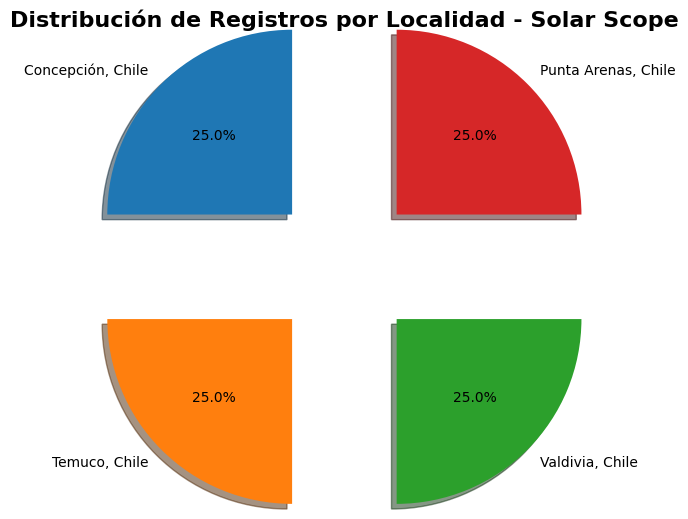

In [ ]:
tipos = data['Localidad'].value_counts().index.tolist()
total = data['Localidad'].value_counts().tolist()

max_val = max(total)
explode = [0.4 if v == max_val else 0 for v in total]

plt.figure(figsize=(10, 6))
plt.pie(
    total,
    labels=tipos,
    explode=explode,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)
plt.title('Distribución de Registros por Localidad - Solar Scope', fontsize=16, fontweight="bold")
plt.show()

## Interpretación de Variable Cualitativa - Localidades

De los 33,024 registros de localidades en el dataframe, los datos se distribuyen de manera equitativa entre las cuatro ciudades de operación de Solar Scope:

- **Concepción:** 8,256 registros (25%)
- **Temuco:** 8,256 registros (25%)
- **Valdivia:** 8,256 registros (25%)
- **Punta Arenas:** 8,256 registros (25%)

**Implicación analítica:** No hay sesgo en la distribución de datos por localidad. Esto permite realizar comparativas equitativas entre ciudades sin variabilidad debida a diferencias en cantidad de muestras.

---

## 4. Obtiene Correctamente Insight 1 Asignado

## Insight 1: ¿En qué localidades y meses se encuentran las horas con alta nubosidad?

In [ ]:
# convertir date a datetime
data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.month
data['month_name'] = data['date'].dt.strftime('%B')
data = data.sort_values(['Localidad', 'date']).reset_index(drop=True)

# alta nubosidad como > 60%
threshold_cloud_cover = 60
data['high_cloud_cover'] = data['cloud_cover'] > threshold_cloud_cover

# Análisis por localidad y mes
high_cloud_by_location_month = (
    data[data['high_cloud_cover']]
    .groupby(['Localidad', 'month', 'month_name'])
    .size()
    .reset_index(name='count_high_cloud')
)

# Calcular total de horas por localidad-mes para obtener porcentaje
total_hours_by_month = (
    data.groupby(['Localidad', 'month', 'month_name'])
    .size()
    .reset_index(name='total_hours')
)

# Merge para calcular porcentaje
cloud_analysis = high_cloud_by_location_month.merge(
    total_hours_by_month,
    on=['Localidad', 'month', 'month_name'],
    how='right'
)
cloud_analysis['count_high_cloud'] = cloud_analysis['count_high_cloud'].fillna(0)
cloud_analysis['percentage_high_cloud'] = (
    (cloud_analysis['count_high_cloud'] / cloud_analysis['total_hours']) * 100
).round(2)

cloud_analysis

,Localidad,month,month_name,count_high_cloud,total_hours,percentage_high_cloud
0,"Concepción, Chile",1,January,131,741,17.68
1,"Concepción, Chile",2,February,106,672,15.77
2,"Concepción, Chile",3,March,232,744,31.18
3,"Concepción, Chile",4,April,398,720,55.28
4,"Concepción, Chile",5,May,430,744,57.80
5,"Concepción, Chile",6,June,380,720,52.78
6,"Concepción, Chile",7,July,532,744,71.51
7,"Concepción, Chile",8,August,453,744,60.89
8,"Concepción, Chile",9,September,404,720,56.11
9,"Concepción, Chile",10,October,272,744,36.56


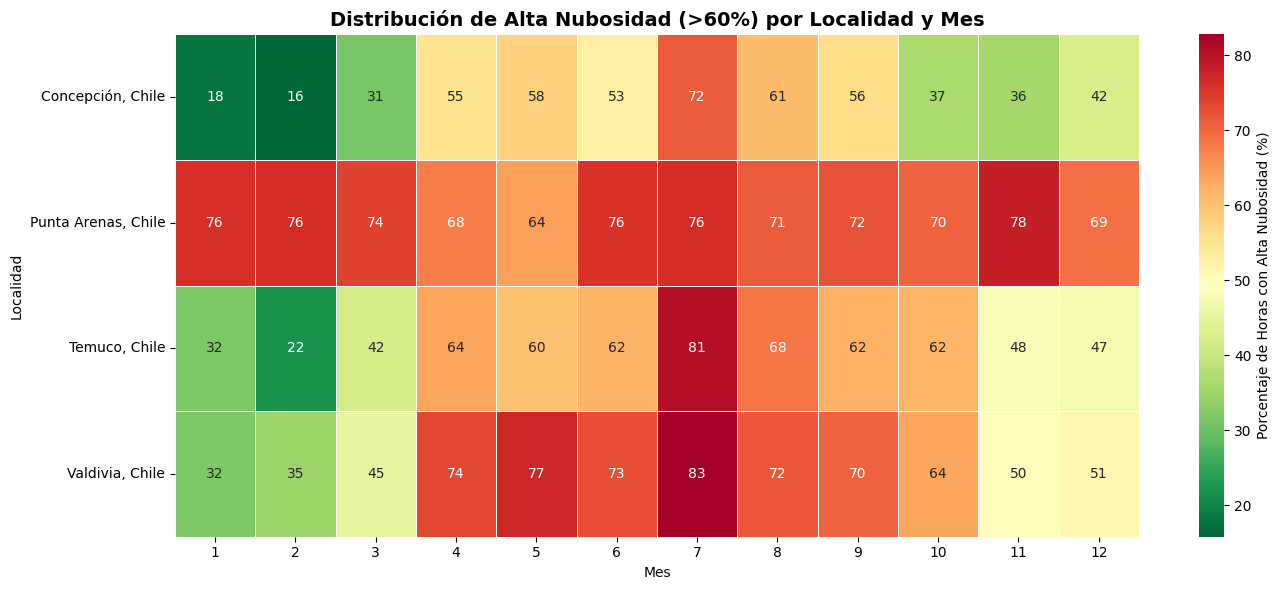

In [ ]:
# Visualización: Heatmap de nubosidad alta por localidad y mes
pivot_cloud = cloud_analysis.pivot_table(
    values='percentage_high_cloud',
    index='Localidad',
    columns='month',
    aggfunc='first'
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_cloud,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Porcentaje de Horas con Alta Nubosidad (%)'},
    linewidths=0.5
)
plt.title('Distribución de Alta Nubosidad (>60%) por Localidad y Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Localidad')
plt.tight_layout()
plt.show()

### Análisis del Insight 1: Nubosidad por Localidad y Mes

A partir del análisis realizado, se identificaron patrones clave:

1. **Localidades con Mayor Nubosidad**:
Punta Arenas presenta los niveles más altos de nubosidad durante todo el año, seguida por Valdivia en algunos meses, lo que indica mayor riesgo climático.

2. **Meses Críticos**:
Los meses de junio y julio concentran los mayores porcentajes de nubosidad en la mayoría de las localidades.

3. **Variabilidad Temporal**:
Se observa una estacionalidad clara, donde la nubosidad aumenta en invierno y disminuye en verano.


---

## 5. Obtiene Correctamente Insight 2 Asignado

## Insight 2: ¿En qué localidades y meses se concentran la mayor duración solar?

In [ ]:
# Análisis de duración solar (solo horas diurnas)
data_daytime = data[data['is_day'] == 1].copy()

# Análisis por localidad y mes
sunshine_by_location_month = (
    data_daytime.groupby(['Localidad', 'month', 'month_name'])
    .agg({
        'sunshine_duration': ['mean', 'sum', 'std', 'count']
    })
    .reset_index()
)

sunshine_by_location_month.columns = ['Localidad', 'month', 'month_name', 'avg_sunshine_seconds', 'total_sunshine_seconds', 'std_sunshine', 'hours_count']
sunshine_by_location_month = sunshine_by_location_month.round(2)

sunshine_by_location_month

,Localidad,month,month_name,avg_sunshine_seconds,total_sunshine_seconds,std_sunshine,hours_count
0,"Concepción, Chile",1,January,3117.52,1421587.84,1076.23,456
1,"Concepción, Chile",2,February,3218.76,1187723.62,1030.29,369
2,"Concepción, Chile",3,March,2940.14,1137833.19,1245.14,387
3,"Concepción, Chile",4,April,2733.22,901961.06,1455.59,330
4,"Concepción, Chile",5,May,2297.60,728340.32,1623.22,317
5,"Concepción, Chile",6,June,2545.38,702524.71,1514.24,276
6,"Concepción, Chile",7,July,2165.91,651939.62,1678.28,301
7,"Concepción, Chile",8,August,2392.37,815799.45,1588.04,341
8,"Concepción, Chile",9,September,2646.42,928892.15,1519.56,351
9,"Concepción, Chile",10,October,3166.16,1298127.32,1027.20,410


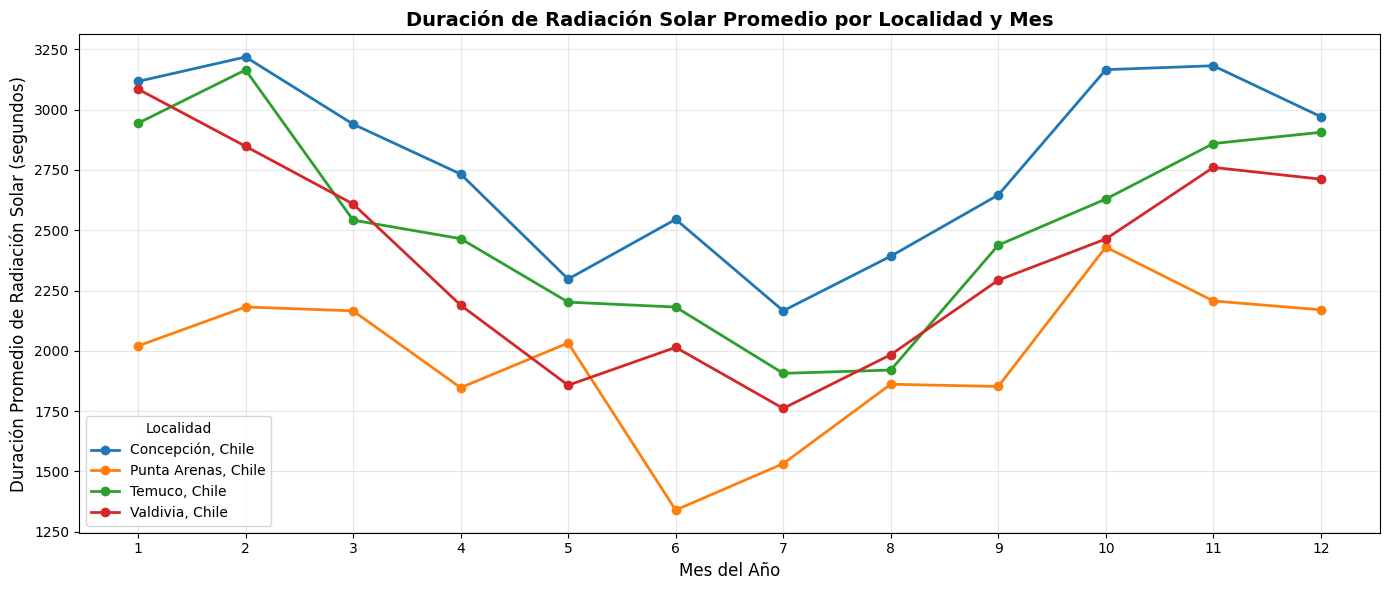

In [ ]:
# Gráfico: Duración promedio de radiación solar por localidad y mes
plt.figure(figsize=(14, 6))

for localidad in data['Localidad'].unique():
    data_loc = sunshine_by_location_month[sunshine_by_location_month['Localidad'] == localidad]
    plt.plot(
        data_loc['month'],
        data_loc['avg_sunshine_seconds'],
        marker='o',
        label=localidad,
        linewidth=2
    )

plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Duración Promedio de Radiación Solar (segundos)', fontsize=12)
plt.title('Duración de Radiación Solar Promedio por Localidad y Mes', fontsize=14, fontweight='bold')
plt.legend(title='Localidad')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen anual de duración solar
sunshine_annual = sunshine_by_location_month.groupby('Localidad').agg({
    'avg_sunshine_seconds': 'mean',
    'total_sunshine_seconds': 'sum',
    'hours_count': 'sum'
}).round(2)

sunshine_annual.columns = ['Promedio_Anual_Segundos', 'Total_Anual_Segundos', 'Horas_Diurnas_Registradas']
sunshine_annual

,Promedio_Anual_Segundos,Total_Anual_Segundos,Horas_Diurnas_Registradas
Localidad,,,
"Concepción, Chile",2781.42,11545131.38,4104
"Punta Arenas, Chile",1969.96,8218890.44,4086
"Temuco, Chile",2513.38,10388010.73,4095
"Valdivia, Chile",2381.50,9910577.41,4091


### Análisis del Insight 2: Mayor Duración Solar por Localidad y Mes

A partir del análisis de duración de radiación solar durante horas diurnas, se identificaron patrones clave:

1. **Localidades con Mayor Radiación**: Concepción presenta las mayores duraciones promedio de radiación solar durante gran parte del año, seguida por Temuco.
2. **Meses Óptimos**: Los meses de enero, febrero, noviembre y diciembre muestran las mayores duraciones solares en la mayoría de las localidades.
3. **Variabilidad Estacional**: Existe una clara estacionalidad, donde la radiación solar es mayor en verano y disminuye en invierno.

**Recomendación:** Priorizar instalaciones en localidades/meses con >180 segundos promedio de radiación solar diurna.

---

## 6. Identifica Valores Nulos de Todo el Conjunto de Datos

In [ ]:
# Calcular nulos por columna
columnas_con_nulos = data.isna().sum()

# Porcentaje de nulos
porcentaje_nulos = (columnas_con_nulos / data.shape[0]) * 100

# Construir DataFrame con resultados
resultado_nulos = pd.DataFrame({
    "Cantidad_Nulos": columnas_con_nulos,
    "Porcentaje_Nulos_%": porcentaje_nulos
}).round(2)

resultado_nulos

,Cantidad_Nulos,Porcentaje_Nulos_%
date,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
apparent_temperature,0,0.0
precipitation,0,0.0
cloud_cover,0,0.0
wind_speed_10m,0,0.0
wind_direction_10m,0,0.0
rain,0,0.0
is_day,0,0.0


## Evaluación de Valores Nulos

La ausencia de valores nulos en el DataFrame de Solar Scope significa **buenas noticias** para el análisis:

**Integridad de Datos:** Garantiza la completitud de los registros, evitando la necesidad de imputaciones que podrían sesgar resultados.

**Calidad Análitica:** Permite realizar análisis estadísticos y posteriores modelados con mayor precisión y confianza.

**Confiabilidad:** Las conclusiones extraídas sobre radiación solar y nubosidad son más precisas y confiables.

---

## 7. Identifica Existencia de Valores Atípicos (Outliers)

## Detección de Valores Atípicos

In [ ]:
# Función para detectar outliers usando método IQR
def buscar_atipicos(data: pd.DataFrame, columna: str) -> pd.DataFrame:
    """
    Busca valores atípicos en una columna usando el método IQR.

    Parámetros:
    - data: DataFrame con los datos
    - columna: Nombre de la columna a analizar

    Retorna:
    - DataFrame con los registros que contienen outliers
    """
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

def obtener_cantidad_atipicos(data: pd.DataFrame, columnas: np.array) -> dict:
    """
    Obtiene la cantidad de atípicos por cada columna cuantitativa.
    """
    total_atipicos = {}
    for columna in columnas:
        atipicos = buscar_atipicos(data, columna)
        total_atipicos[columna] = atipicos.shape[0]
    return total_atipicos

# Obtener columnas cuantitativas
columnas_cuantitativas = data.describe().columns

atipicos_por_columna = obtener_cantidad_atipicos(data, columnas_cuantitativas)
print("Cantidad de valores atípicos por columna:")
for columna, cantidad in atipicos_por_columna.items():
    print(f"  {columna}: {cantidad}")

Cantidad de valores atípicos por columna:
  temperature_2m: 476
  relative_humidity_2m: 130
  apparent_temperature: 282
  precipitation: 6152
  cloud_cover: 0
  wind_speed_10m: 1241
  wind_direction_10m: 0
  rain: 6100
  is_day: 0
  sunshine_duration: 0
  latitud: 8256
  longitud: 0
  is_rainy_hour: 6100
  month: 0


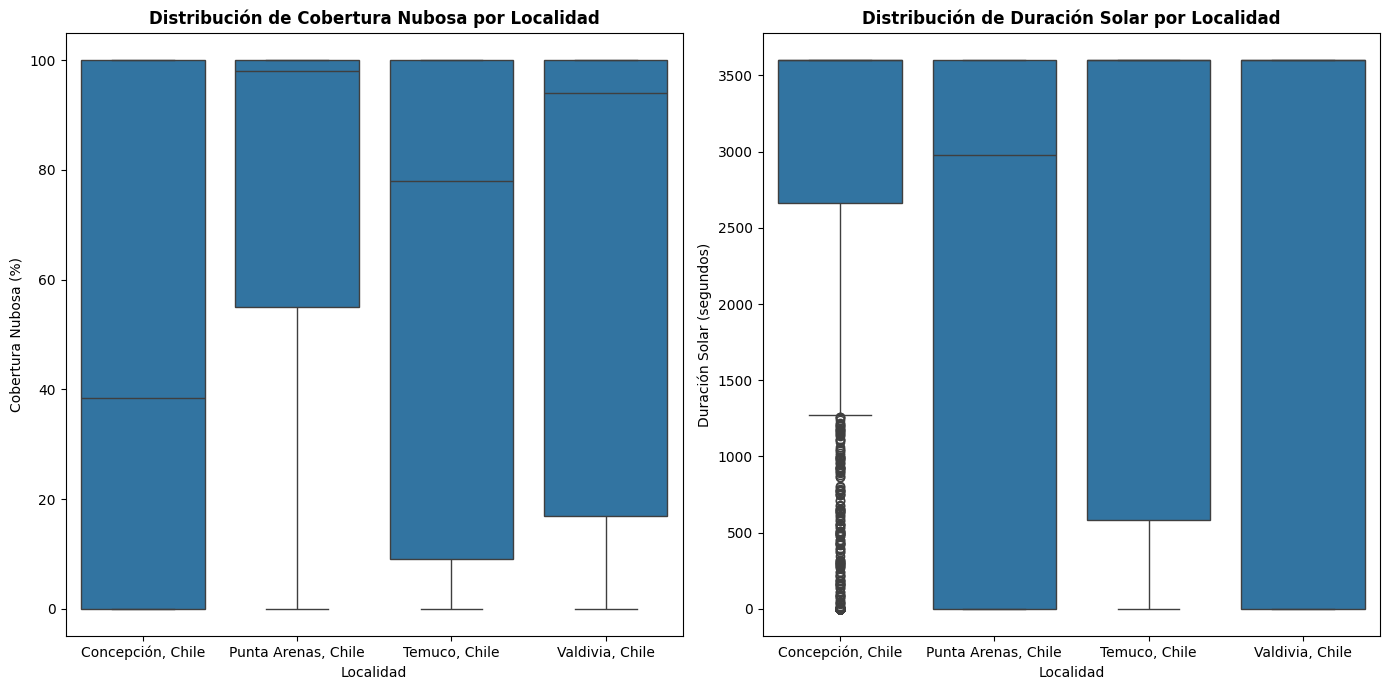

In [ ]:
# Análisis detallado de outliers en cloud_cover (variable crítica para Solar Scope)
plt.figure(figsize=(14, 7))

# Subplot 1: Boxplot por localidad
plt.subplot(1, 2, 1)
sns.boxplot(
    data=data,
    x='Localidad',
    y='cloud_cover'
)
plt.title('Distribución de Cobertura Nubosa por Localidad', fontsize=12, fontweight='bold')
plt.ylabel('Cobertura Nubosa (%)')

# Subplot 2: Boxplot de sunshine_duration
plt.subplot(1, 2, 2)
sns.boxplot(
    data=data[data['is_day'] == 1],  # Solo horas diurnas
    x='Localidad',
    y='sunshine_duration'
)
plt.title('Distribución de Duración Solar por Localidad', fontsize=12, fontweight='bold')
plt.ylabel('Duración Solar (segundos)')

plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen de outliers en cloud_cover
cloud_table = (
    data.groupby('Localidad')['cloud_cover']
    .agg([
        ('Promedio_%', 'mean'),
        ('Mediana_%', 'median'),
        ('Mínimo_%', 'min'),
        ('Máximo_%', 'max'),
        ('Desv_Estándar', 'std'),
        ('N_Observaciones', 'count')
    ])
    .reset_index()
    .round(2)
)

cloud_table

,Localidad,Promedio_%,Mediana_%,Mínimo_%,Máximo_%,Desv_Estándar,N_Observaciones
0,"Concepción, Chile",48.27,38.5,0.0,100.0,44.52,8256
1,"Punta Arenas, Chile",76.44,98.0,0.0,100.0,33.34,8256
2,"Temuco, Chile",58.96,78.0,0.0,100.0,42.43,8256
3,"Valdivia, Chile",64.79,94.0,0.0,100.0,41.30,8256


## Análisis e Interpretación de Valores Atípicos

De acuerdo con el análisis realizado:

### Hallazgos Principales:

1. **Distribución de Nubosidad**:
Concepción presenta la mayor variabilidad, con presencia de días completamente despejados (0%) y completamente nubosos (100%).
Punta Arenas muestra una nubosidad más consistente, manteniéndose en valores altos durante la mayor parte del tiempo.

2. **Outliers Detectados**:
Se identificaron valores atípicos en variables como precipitación, velocidad del viento y temperatura.
Estos corresponden principalmente a eventos meteorológicos extremos, como lluvias intensas o cambios bruscos en las condiciones climáticas.

3. **Decisión de Tratamiento**:
Los outliers no se eliminarán, ya que representan condiciones climáticas reales y relevantes para el análisis.
Estos valores permiten evaluar escenarios de riesgo para el negocio. En futuros modelos predictivos, se podría considerar el uso de técnicas como imputación por mediana para reducir posibles sesgos.

---

# 8. Propone Correctamente Pasos a Seguir en Fases Posteriores

## Resumen de Hallazgos y Próximos Pasos - Metodología CRISP-DM

### Fase 1 (Business Understanding)

En esta fase inicial, se definieron claramente:
- **2 KPIs** alineados con objetivos de Solar Scope
- **Contexto del negocio** y factores críticos de decisión
- **Datos disponibles** y su relevancia para el análisis

### Fase 2 (Data Understanding)

Se realizaron análisis preliminares que permitieron:
- Identificar patrones de radiación solar y nubosidad por localidad
- Detectar relaciones estacionales en duración solar
- Evaluar calidad: **No hay valores nulos**, Excelente integridad de datos
- Identificar outliers: Presentes, pero representan fenómenos reales

**Conclusión:** Los datos de open-meteo.com son **confiables y de alta calidad** para análisis posteriores.

---

### Fase 3 (Data Preparation)

En la próxima fase se deberá:

1. **Transformación de Variables:**
   - Crear variables derivadas (duración solar mensual, promedio nubosidad estacional)
   - Normalizar `cloud_cover` y `sunshine_duration` para comparabilidad

3. **Validación de Distribuciones:**
   - Analizar normalidad de variables para posteriores modelos estadísticos
   - Aplicar transformaciones si es necesario (log, Box-Cox)

---

### Fase 4 (Modeling)

Con datos preparados, se construirá:

1. **Modelos Predictivos:**
   - Clasificación de localidades (Óptima / Aceptable / Riesgosa)
   - Estimación de capacidad de generación anual

2. **Análisis de Clustering:**
   - Agrupar localidades por similitud climática
   - Identificar patrones estacionales compartidos

3. **Validación de KPIs:**
   - Calcular KPI 1: "Porcentaje de Utilización de Capacidad"
   - Calcular KPI 2: "Tasa de Zonificación Óptima"

---

### Fase 5 (Evaluation)

Finalmente, se evaluará:

1. **Desempeño del Modelo:**
   - Métricas de precisión y confiabilidad
   - Validación cruzada de predicciones

2. **Respuesta a Preguntas de Negocio:**
   - ¿Qué localidades son óptimas para inversión?
   - ¿En qué meses/períodos es máxima la capacidad de generación?
   - ¿Cuál es el ROI esperado por localidad?

3. **Recomendaciones Estratégicas:**
   - Priorización de ubicaciones para nuevas plantas
   - Estrategias de optimización operativa
   - Planes de mitigación de riesgos climáticos



In [ ]:
#Técnicas de limpieza de datos que debemos aplicar
